In [ ]:
# 한글 폰트 설치
# !sudo apt-get install -y fonts-nanum
# 폰트 설치 후 Colab 메뉴에서 런타임/세션 다시 시작을 선택합니다.

In [ ]:
# Colab 환경 설정
# !pip install -U openai

In [1]:
# from google.colab import userdata
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# 환경 변수에서 가져오기
api_key = os.getenv("OPENAI_API_KEY")

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = api_key

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

import openai

client = openai.OpenAI()

In [2]:
import json

# 프롬프트 평가 함수
def evaluate_prompt(prompt, response):
    eval_messages = [
        {
            "role": "user",
            "content": f"""프롬프트에 대한 응답을 정확성, 형식충실도, 간결성으로 평가(1~10점)하고 결과를 JSON 형식으로 반환합니다.
                        정확성은 사실/지시와 일치 여부, 형식충실도는 요청된 출력형식 준수 여부, 간결성은 불필요한 내용 없이 요점을 담았는지를 판단합니다.
                        프롬프트: {prompt}
                        응답: {response}
                        결과:
                        {{ '정확성': 8, '형식충실도': 10, '간결성': 7 }}
                        """}
    ]
    eval_response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=eval_messages,
        response_format={"type": "json_object"}
    )
    content = eval_response.choices[0].message.content

    try:
        result = json.loads(content)
        print(result)
        return result
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON: {e}\nContent: {content}")
        return {}

# Iterative Tuning 실습 데이터
prompts = [
    "다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 분야에서 활용되고 있다. 향후 더욱 더 발전할 것이다.'",
    "대한민국의 수도는 어디인가요?",
    "이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",
    "리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요."
]

iterations_results = []

# Iterative Tuning 루프 (예시로 3회 반복)
for iteration in range(3):
    print(f"Iteration {iteration + 1} 시작")
    for prompt in prompts:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}]
        ).choices[0].message.content

        eval_scores = evaluate_prompt(prompt, response)
        eval_scores["prompt"] = prompt
        eval_scores["response"] = response
        eval_scores["iteration"] = iteration + 1
        iterations_results.append(eval_scores)

Iteration 1 시작
{'정확성': 9, '형식충실도': 10, '간결성': 8}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 9}
{'정확성': 10, '형식충실도': 10, '간결성': 8}
Iteration 2 시작
{'정확성': 9, '형식충실도': 10, '간결성': 8}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 9, '형식충실도': 10, '간결성': 8}
Iteration 3 시작
{'정확성': 9, '형식충실도': 10, '간결성': 8}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 9}
{'정확성': 10, '형식충실도': 10, '간결성': 9}


In [3]:
from pprint import pprint
pprint(iterations_results)

[{'iteration': 1,
  'prompt': "다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 분야에서 활용되고 있다. 향후 더욱 "
            "더 발전할 것이다.'",
  'response': '인공지능은 다양한 분야에서 빠르게 발전하고 있으며, 앞으로 더욱 발전할 것이다.',
  '간결성': 8,
  '정확성': 9,
  '형식충실도': 10},
 {'iteration': 1,
  'prompt': '대한민국의 수도는 어디인가요?',
  'response': '대한민국의 수도는 서울입니다.',
  '간결성': 10,
  '정확성': 10,
  '형식충실도': 10},
 {'iteration': 1,
  'prompt': "이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",
  'response': '주어진 문장을 JSON 형식으로 변환하면 다음과 같습니다:\n'
              '\n'
              '```json\n'
              '{\n'
              '  "이름": "김철수",\n'
              '  "나이": 25\n'
              '}\n'
              '```',
  '간결성': 9,
  '정확성': 10,
  '형식충실도': 10},
 {'iteration': 1,
  'prompt': '리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.',
  'response': '리스트를 입력받아 역순으로 반환하는 파이썬 함수를 다음과 같이 작성할 수 있습니다:\n'
              '\n'
              '```python\n'
              'def reverse_list(input_list):\n'
              '    return input_list[::-1]\n'
              '\n'
              '# 

In [4]:
import pandas as pd

# 결과 데이터프레임 생성
df = pd.DataFrame(iterations_results)
df

,정확성,형식충실도,간결성,prompt,response,iteration
0,9,10,8,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,"인공지능은 다양한 분야에서 빠르게 발전하고 있으며, 앞으로 더욱 발전할 것이다.",1
1,10,10,10,대한민국의 수도는 어디인가요?,대한민국의 수도는 서울입니다.,1
2,10,10,9,"이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",주어진 문장을 JSON 형식으로 변환하면 다음과 같습니다:\n\n```json\n{...,1
3,10,10,8,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 다음과 같이 작성할 수 있습니다:...,1
4,9,10,8,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,"인공지능은 빠르게 발전하며 다양한 분야에서 활용되고 있고, 앞으로도 더욱 발전할 것...",2
5,10,10,10,대한민국의 수도는 어디인가요?,대한민국의 수도는 서울입니다.,2
6,10,10,10,"이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",다음은 주어진 문장을 JSON 형식으로 변환한 예입니다:\n\n```json\n{\...,2
7,9,10,8,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.,리스트를 역순으로 반환하는 파이썬 함수를 작성하는 것은 매우 간단합니다. 아래는 그...,2
8,9,10,8,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,인공지능은 다양한 분야에서 빠르게 발전하고 있으며 앞으로 더욱 성장할 것이다.,3
9,10,10,10,대한민국의 수도는 어디인가요?,대한민국의 수도는 서울입니다.,3


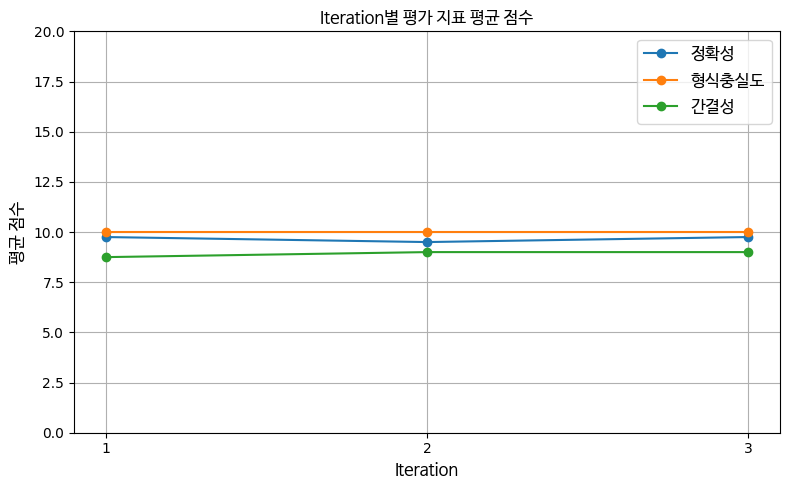

In [5]:
import matplotlib.pyplot as plt

# 시각화
import matplotlib.font_manager as fm

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

plt.figure(figsize=(8, 5))
for metric in ["정확성", "형식충실도", "간결성"]:
    metric_mean = df.groupby('iteration')[metric].mean()
    plt.plot(metric_mean.index, metric_mean.values, marker='o', label=metric)

plt.title('Iteration별 평가 지표 평균 점수', fontproperties=fontprop)
plt.xlabel('Iteration', fontproperties=fontprop)
plt.ylabel('평균 점수', fontproperties=fontprop)
plt.ylim(0, 20)
plt.xticks(range(1, 4))
plt.legend(prop=fontprop)
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
def modify_prompt(base_prompt, iteration):
    """
    Iteration에 따라 프롬프트를 개선하는 함수
    """
    if iteration == 0:
        return base_prompt
    elif iteration == 1:
        # 간단한 명시적 지시 추가
        return f"{base_prompt} (명확하게, 핵심만 간단히 작성해 주세요)"
    elif iteration == 2:
        # 출력 형식 또는 예시 추가
        if "JSON" in base_prompt:
            return f"{base_prompt} (예: {{\"이름\": \"홍길동\", \"나이\": 30}} 형태로 작성)"
        elif "요약" in base_prompt:
            return f"{base_prompt} (한 문장으로 요약해 주세요. 불필요한 정보는 제외)"
        elif "함수" in base_prompt:
            return f"{base_prompt} (주석을 포함해 작성하고, 예시 입력/출력도 함께 제공해 주세요)"
        else:
            return base_prompt + " (더 간결하고 형식에 맞게 작성해 주세요)"
    else:
        return base_prompt  # fallback


# 실험용 프롬프트 (원본)
base_prompts = [
    "다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 분야에서 활용되고 있다. 향후 더욱 더 발전할 것이다.'",
    "대한민국의 수도는 어디인가요?",
    "이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",
    "리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요."
]

# 결과 저장 리스트
iterations_results = []

# Iterative Prompt Tuning
for iteration in range(3):
    print(f"\n🚀 Iteration {iteration + 1} 시작")
    for base_prompt in base_prompts:
        prompt = modify_prompt(base_prompt, iteration)

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}]
        ).choices[0].message.content

        eval_scores = evaluate_prompt(prompt, response)
        eval_scores["base_prompt"] = base_prompt
        eval_scores["modified_prompt"] = prompt
        eval_scores["response"] = response
        eval_scores["iteration"] = iteration + 1
        iterations_results.append(eval_scores)


🚀 Iteration 1 시작
{'정확성': 9, '형식충실도': 10, '간결성': 8}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 8, '형식충실도': 10, '간결성': 7}

🚀 Iteration 2 시작
{'정확성': 9, '형식충실도': 10, '간결성': 8}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 8}

🚀 Iteration 3 시작
{'정확성': 8, '형식충실도': 10, '간결성': 7}
{'정확성': 10, '형식충실도': 10, '간결성': 10}
{'정확성': 10, '형식충실도': 10, '간결성': 9}
{'정확성': 10, '형식충실도': 10, '간결성': 9}


In [7]:
# 결과 데이터프레임 생성
df = pd.DataFrame(iterations_results)
df

,정확성,형식충실도,간결성,base_prompt,modified_prompt,response,iteration
0,9,10,8,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,"인공지능은 다양한 분야에서 빠르게 발전하고 있으며, 앞으로도 계속해서 발전할 것이다.",1
1,10,10,10,대한민국의 수도는 어디인가요?,대한민국의 수도는 어디인가요?,대한민국의 수도는 서울입니다.,1
2,10,10,10,"이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'","이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'",다음과 같이 JSON 형식으로 변환할 수 있습니다:\n\n```json\n{\n ...,1
3,8,10,7,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성하는 방법은 여러 가지가 있습...,1
4,9,10,8,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,인공지능은 빠르게 발전하며 다양한 분야에서 활용되고 앞으로 더욱 발전할 것이다.,2
5,10,10,10,대한민국의 수도는 어디인가요?,"대한민국의 수도는 어디인가요? (명확하게, 핵심만 간단히 작성해 주세요)",대한민국의 수도는 서울입니다.,2
6,10,10,10,"이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25'","이 문장을 JSON 형식으로 변환하세요: '이름: 김철수, 나이: 25' (명확하게...","```json\n{\n ""이름"": ""김철수"",\n ""나이"": 25\n}\n```",2
7,10,10,8,리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요.,"리스트를 입력받아 역순으로 반환하는 파이썬 함수를 작성해 주세요. (명확하게, 핵심...",아래는 리스트를 역순으로 반환하는 파이썬 함수입니다.\n\n```python\nde...,2
8,8,10,7,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,다음 글을 한 문장으로 요약해 주세요: '인공지능은 빠르게 발전하고 있다. 다양한 ...,인공지능은 빠르게 발전하고 있으며 다양한 분야에서 활용될 것이다.,3
9,10,10,10,대한민국의 수도는 어디인가요?,대한민국의 수도는 어디인가요? (더 간결하고 형식에 맞게 작성해 주세요),대한민국의 수도는 서울입니다.,3
